# Module 3 - Assignment 2: Unsupervised Learning
### DS23 - Credit Card Behavioral Segmentation
**Author:** Orarr2
**Chosen Option:** B (Credit Card behavioral segmentation, Kaggle: arjunbhasin2013/ccdata)
**Business framing:** Risk & Credit Policy

This notebook implements customer segmentation on credit card behavioral data with a risk-policy framing. The full reasoning, dilemmas, and limitations are discussed in REPORT.md.

**Workflow (6 stations):**
1. Frame the structure and business decision
2. Data + scaling
3. Build at least two approaches
4. Validate
5. Interrogate
6. Translate to action (Structure Card)

There is no ground truth here. "Good" is something we argue for, not measure.

## Part 1 - Setup, data, scaling

In [1]:
import importlib, subprocess, sys

REQUIRED = [
    ("numpy",      None),
    ("pandas",     None),
    ("scipy",      None),
    ("sklearn",    "scikit-learn"),
    ("matplotlib", None),
    ("plotly",     None),
]

def ensure(import_name, pip_name=None):
    pkg = pip_name or import_name
    try:
        mod = importlib.import_module(import_name)
    except ImportError:
        print(f"  installing {pkg} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", pkg]
        )
        mod = importlib.import_module(import_name)
    ver = getattr(mod, "__version__", "unknown")
    print(f"  {import_name:<12s} == {ver}")
    return mod

print("Library check:")
for name, pip_name in REQUIRED:
    ensure(name, pip_name)
print(f"  {'python':<12s} == {sys.version.split()[0]}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import kruskal
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

plt.rcParams.update({
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})

Library check:
  numpy        == 2.3.5
  pandas       == 2.3.3
  scipy        == 1.16.3
  sklearn      == 1.7.2
  matplotlib   == 3.10.6
  plotly       == 6.3.0
  python       == 3.13.9


  numpy        == 2.0.2


  pandas       == 2.3.3
  scipy        == 1.13.1


  sklearn      == 1.6.1


  matplotlib   == 3.9.4
  plotly       == 6.8.0
  python       == 3.9.2


### Load Credit Card data

Download `CC GENERAL.csv` from Kaggle (arjunbhasin2013/ccdata) and place it next to this notebook (or adjust the path below).

In [2]:
DATA_PATH = "CC GENERAL.csv"

def load_credit_card(path=DATA_PATH):
    df = pd.read_csv(path)
    df = df.drop(columns=["CUST_ID"])
    return df

df_raw = load_credit_card()
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Shape: (8950, 17)
Columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.0,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12


In [3]:
print("Missing values (where >0):")
miss = df_raw.isnull().sum()
print(miss[miss > 0])

print("\nFeature scales (selected):")
print(df_raw.describe().T[["min", "max", "mean", "50%", "std"]].round(2))

print("\nSkewness of amount features:")
amount_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
               "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]
for c in amount_cols:
    print(f"  {c}: skew = {df_raw[c].skew():.2f}")

Missing values (where >0):
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Feature scales (selected):
                                    min       max     mean      50%      std
BALANCE                            0.00  19043.14  1564.47   873.39  2081.53
BALANCE_FREQUENCY                  0.00      1.00     0.88     1.00     0.24
PURCHASES                          0.00  49039.57  1003.20   361.28  2136.63
ONEOFF_PURCHASES                   0.00  40761.25   592.44    38.00  1659.89
INSTALLMENTS_PURCHASES             0.00  22500.00   411.07    89.00   904.34
CASH_ADVANCE                       0.00  47137.21   978.87     0.00  2097.16
PURCHASES_FREQUENCY                0.00      1.00     0.49     0.50     0.40
ONEOFF_PURCHASES_FREQUENCY         0.00      1.00     0.20     0.08     0.30
PURCHASES_INSTALLMENTS_FREQUENCY   0.00      1.00     0.36     0.17     0.40
CASH_ADVANCE_FREQUENCY             0.00      1.50     0.14     0.00     0.20
CASH_ADVANCE_TRX                   0.

                                    min       max     mean      50%      std
BALANCE                            0.00  19043.14  1564.47   873.39  2081.53
BALANCE_FREQUENCY                  0.00      1.00     0.88     1.00     0.24
PURCHASES                          0.00  49039.57  1003.20   361.28  2136.63
ONEOFF_PURCHASES                   0.00  40761.25   592.44    38.00  1659.89
INSTALLMENTS_PURCHASES             0.00  22500.00   411.07    89.00   904.34
CASH_ADVANCE                       0.00  47137.21   978.87     0.00  2097.16
PURCHASES_FREQUENCY                0.00      1.00     0.49     0.50     0.40
ONEOFF_PURCHASES_FREQUENCY         0.00      1.00     0.20     0.08     0.30
PURCHASES_INSTALLMENTS_FREQUENCY   0.00      1.00     0.36     0.17     0.40
CASH_ADVANCE_FREQUENCY             0.00      1.50     0.14     0.00     0.20
CASH_ADVANCE_TRX                   0.00    123.00     3.25     0.00     6.82
PURCHASES_TRX                      0.00    358.00    14.71     7.00    24.86

### Data Card

Short reference for the raw dataset: source, schema, sample rows, summary stats.

In [4]:
COLUMN_DESCRIPTIONS = {
    "BALANCE":                          "Current outstanding balance.",
    "BALANCE_FREQUENCY":                "How frequently the balance is updated (0=never, 1=constantly).",
    "PURCHASES":                        "Total purchases amount over the period.",
    "ONEOFF_PURCHASES":                 "One-off (non-installment) purchase amount.",
    "INSTALLMENTS_PURCHASES":           "Installment-based purchase amount.",
    "CASH_ADVANCE":                     "Cash advance amount.",
    "PURCHASES_FREQUENCY":              "Frequency of any purchases.",
    "ONEOFF_PURCHASES_FREQUENCY":       "Frequency of one-off purchases.",
    "PURCHASES_INSTALLMENTS_FREQUENCY": "Frequency of installment purchases.",
    "CASH_ADVANCE_FREQUENCY":           "Frequency of cash advances.",
    "CASH_ADVANCE_TRX":                 "Number of cash-advance transactions.",
    "PURCHASES_TRX":                    "Number of purchase transactions.",
    "CREDIT_LIMIT":                     "Customer's credit limit.",
    "PAYMENTS":                         "Total amount paid by the customer.",
    "MINIMUM_PAYMENTS":                 "Minimum payment required.",
    "PRC_FULL_PAYMENT":                 "Fraction of months the customer paid in full.",
    "TENURE":                           "Months of card tenure.",
}

print("Source : kaggle.com/datasets/arjunbhasin2013/ccdata")
print(f"File   : CC GENERAL.csv")
print(f"Rows   : {len(df_raw):,} customers")
print(f"Columns: {df_raw.shape[1]}")

schema_rows = []
for col in df_raw.columns:
    s = df_raw[col]
    miss_pct = s.isna().mean() * 100
    rng = f"{s.min():,.2f} - {s.max():,.2f}" if pd.api.types.is_numeric_dtype(s) else "-"
    schema_rows.append({
        "column": col,
        "dtype": str(s.dtype),
        "range": rng,
        "missing": f"{int(s.isna().sum())} ({miss_pct:.1f}%)" if miss_pct > 0 else "0",
        "description": COLUMN_DESCRIPTIONS.get(col, ""),
    })
schema_df = pd.DataFrame(schema_rows)

print("\nSchema:")
print(schema_df.to_string(index=False))

print("\nSample rows:")
print(df_raw.head(3).round(2).to_string())

amount_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS",
               "MINIMUM_PAYMENTS", "PRC_FULL_PAYMENT", "TENURE"]
summary = df_raw[amount_cols].agg(["mean", "median", "std", "skew"]).T.round(2)
print("\nSummary statistics:")
print(summary.to_string())

Source : kaggle.com/datasets/arjunbhasin2013/ccdata
File   : CC GENERAL.csv
Rows   : 8,950 customers
Columns: 17

Schema:
                          column   dtype             range    missing                                                    description
                         BALANCE float64  0.00 - 19,043.14          0                                   Current outstanding balance.
               BALANCE_FREQUENCY float64       0.00 - 1.00          0 How frequently the balance is updated (0=never, 1=constantly).
                       PURCHASES float64  0.00 - 49,039.57          0                        Total purchases amount over the period.
                ONEOFF_PURCHASES float64  0.00 - 40,761.25          0                     One-off (non-installment) purchase amount.
          INSTALLMENTS_PURCHASES float64  0.00 - 22,500.00          0                             Installment-based purchase amount.
                    CASH_ADVANCE float64  0.00 - 47,137.21          0           


Schema:
                          column   dtype             range    missing                                                    description
                         BALANCE float64  0.00 - 19,043.14          0                                   Current outstanding balance.
               BALANCE_FREQUENCY float64       0.00 - 1.00          0 How frequently the balance is updated (0=never, 1=constantly).
                       PURCHASES float64  0.00 - 49,039.57          0                        Total purchases amount over the period.
                ONEOFF_PURCHASES float64  0.00 - 40,761.25          0                     One-off (non-installment) purchase amount.
          INSTALLMENTS_PURCHASES float64  0.00 - 22,500.00          0                             Installment-based purchase amount.
                    CASH_ADVANCE float64  0.00 - 47,137.21          0                                           Cash advance amount.
             PURCHASES_FREQUENCY float64       0.00 - 1.00  

### Missing values

`MINIMUM_PAYMENTS` has 313 missing rows. Investigation showed these are not random: they are dormant customers (median BALANCE 17, 75th percentile of PAYMENTS = 0, all with PRC_FULL_PAYMENT = 0). The honest fill value is 0: there is no balance to charge minimum on, so no minimum payment exists. Filling with the median would falsely position them as average customers.

`CREDIT_LIMIT` has 1 missing row, filled with median.

`CASH_ADVANCE_FREQUENCY` has 8 customers with values > 1 (up to 1.5), beyond the documented 0-1 range. Kept as is: they carry real risk signal.

In [5]:
def handle_missing(df):
    df = df.copy()
    df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(0)
    df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
    return df

df_clean = handle_missing(df_raw)

remaining = int(df_clean.isnull().sum().sum())
oor_caf  = int((df_clean["CASH_ADVANCE_FREQUENCY"] > 1).sum())
print(f"Missing values after handling: {remaining}")
print(f"Customers with CASH_ADVANCE_FREQUENCY > 1 (kept as is): {oor_caf}")

Missing values after handling: 0
Customers with CASH_ADVANCE_FREQUENCY > 1 (kept as is): 8


### Feature engineering and selection

We drop two features and add three risk-relevant ratios.

**Drop:**
- `TENURE`: 84.7% of customers have TENURE = 12 (near-constant feature).
- `PURCHASES`: nearly equal to `ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES` (correlation 0.92 with ONEOFF). Dropping reduces double-weighting of the spending dimension.

**Add (risk-relevant ratios):**
- `utilization_ratio = BALANCE / CREDIT_LIMIT`: the classic credit risk indicator.
- `payment_to_min_ratio = PAYMENTS / (MINIMUM_PAYMENTS + 1)`: how much above the minimum the customer pays.
- `cash_advance_share = CASH_ADVANCE / (CASH_ADVANCE + PURCHASES + 1)`: what share of total card use is debt-like.

In [6]:
def engineer_features(df):
    df = df.copy()
    df["utilization_ratio"] = df["BALANCE"] / df["CREDIT_LIMIT"]
    df["payment_to_min_ratio"] = df["PAYMENTS"] / (df["MINIMUM_PAYMENTS"] + 1)
    df["cash_advance_share"] = df["CASH_ADVANCE"] / (df["CASH_ADVANCE"] + df["PURCHASES"] + 1)
    df = df.drop(columns=["TENURE", "PURCHASES"])
    return df

df_features = engineer_features(df_clean)
print(f"Feature space after engineering: {df_features.shape[1]} columns")
print(f"Columns: {list(df_features.columns)}")
df_features.head(3)

Feature space after engineering: 18 columns
Columns: ['BALANCE', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'utilization_ratio', 'payment_to_min_ratio', 'cash_advance_share']


,BALANCE,BALANCE_FREQUENCY,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,utilization_ratio,payment_to_min_ratio,cash_advance_share
0,40.900749,0.818182,0.00,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,0.040901,1.436214,0.000000
1,3202.467416,0.909091,0.00,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,0.457495,3.822677,0.999845
2,2495.148862,1.000000,773.17,0.0,0.000000,1.000000,1.0,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,0.332687,0.990103,0.000000


### Scaling: log1p + RobustScaler

We apply `log1p` to features with right-skew above 2 (compresses extreme tails), then `RobustScaler` (median + IQR) instead of StandardScaler so remaining outliers don't dominate the scale. Tested StandardScaler alone first but it gave very unbalanced cluster sizes due to outlier dominance (max z-score 77 on `payment_to_min_ratio`).

Log-transformed columns (10): ['BALANCE', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'utilization_ratio', 'payment_to_min_ratio']
Final feature space: (8950, 18)


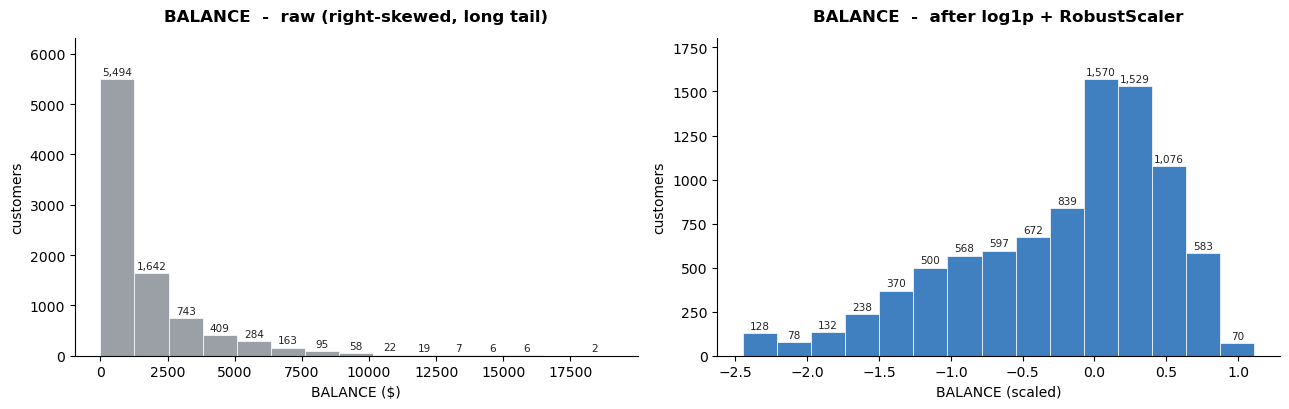

In [7]:
def apply_log_and_scale(df, skew_threshold=2.0):
    df_log = df.copy()
    log_cols = []
    for c in df_log.columns:
        if (df_log[c] >= 0).all() and df_log[c].skew() > skew_threshold:
            df_log[c] = np.log1p(df_log[c])
            log_cols.append(c)
    X = RobustScaler().fit_transform(df_log)
    return X, log_cols

X, log_cols = apply_log_and_scale(df_features)
print(f"Log-transformed columns ({len(log_cols)}): {log_cols}")
print(f"Final feature space: {X.shape}")


def _annotate_all_bars(ax, counts, edges, min_count=1):
    for cnt, e0, e1 in zip(counts, edges[:-1], edges[1:]):
        if cnt >= min_count:
            x = (e0 + e1) / 2
            ax.annotate(f"{int(cnt):,}",
                        xy=(x, cnt), xytext=(0, 3), textcoords="offset points",
                        ha="center", fontsize=7.5, color="#222")


fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

c0, edges0, _ = axes[0].hist(df_features["BALANCE"], bins=15, color="#9aa0a6",
                              edgecolor="white", linewidth=0.5)
axes[0].set_title("BALANCE  -  raw (right-skewed, long tail)")
axes[0].set_xlabel("BALANCE ($)")
axes[0].set_ylabel("customers")
axes[0].set_ylim(0, c0.max() * 1.15)
_annotate_all_bars(axes[0], c0, edges0)

balance_idx = list(df_features.columns).index("BALANCE")
c1, edges1, _ = axes[1].hist(X[:, balance_idx], bins=15, color="#4080c0",
                              edgecolor="white", linewidth=0.5)
axes[1].set_title("BALANCE  -  after log1p + RobustScaler")
axes[1].set_xlabel("BALANCE (scaled)")
axes[1].set_ylabel("customers")
axes[1].set_ylim(0, c1.max() * 1.15)
_annotate_all_bars(axes[1], c1, edges1)

plt.tight_layout()
plt.show()

## Part 2 - Build at least two approaches

### k selection: Elbow + Silhouette

 k    inertia  silhouette
 2 107704.788       0.372
 3  78035.969       0.417
 4  66691.994       0.249
 5  61314.502       0.237
 6  56799.027       0.235
 7  53116.852       0.238
 8  49065.958       0.211
 9  46474.009       0.212
10  43654.728       0.216


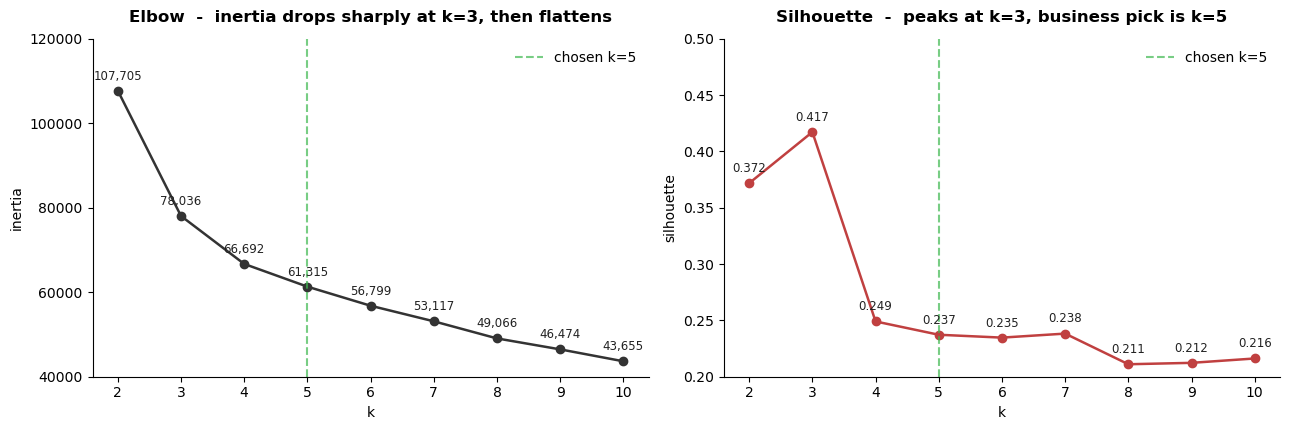

In [25]:
ks = list(range(2, 11))
inertias, sils, models = [], [], {}
for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    inertias.append(km_k.inertia_)
    sils.append(silhouette_score(X, km_k.labels_))
    models[k] = km_k

selection_df = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": sils}).round(3)
print(selection_df.to_string(index=False))


def _label_points(ax, xs, ys, fmt, dy=8):
    for x, y in zip(xs, ys):
        ax.annotate(fmt.format(y),
                    xy=(x, y), xytext=(0, dy), textcoords="offset points",
                    ha="center", fontsize=8.5, color="#222")


fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

elbow_bottom = int(np.floor(min(inertias) / 20000) * 20000)
elbow_top    = int(np.ceil(max(inertias)  / 20000) * 20000)
elbow_ticks  = list(range(elbow_bottom, elbow_top + 1, 20000))

axes[0].plot(ks, inertias, marker="o", color="#333", linewidth=1.8)
axes[0].axvline(5, color="#3fb950", linestyle="--", alpha=0.7, label="chosen k=5")
axes[0].set_title("Elbow  -  inertia drops sharply at k=3, then flattens")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_xticks(ks)
axes[0].set_ylim(elbow_bottom, elbow_top)
axes[0].set_yticks(elbow_ticks)
_label_points(axes[0], ks, inertias, "{:,.0f}")
axes[0].legend(loc="upper right", frameon=False)

sil_ticks = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
axes[1].plot(ks, sils, marker="o", color="#c04040", linewidth=1.8)
axes[1].axvline(5, color="#3fb950", linestyle="--", alpha=0.7, label="chosen k=5")
axes[1].set_title("Silhouette  -  peaks at k=3, business pick is k=5")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
axes[1].set_xticks(ks)
axes[1].set_ylim(0.20, 0.50)
axes[1].set_yticks(sil_ticks)
_label_points(axes[1], ks, sils, "{:.3f}")
axes[1].legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

**Reading the curves:** Silhouette peaks at k=3 (0.42), and the Elbow drops sharply at k=3 then decelerates. Both metrics suggest k=3.

But k=3 collapses 72% of customers into one mixed cluster (revolvers + heavy spenders + cash-advance heavy all together). For a Risk framing this is unusable: we need to distinguish cash-advance heavy from heavy spenders from light revolvers.

I chose k=5 on business grounds, accepting the silhouette cost (0.24 vs 0.42 at k=3). This is the metric-vs-business dilemma that question 2 of REPORT.md asks about.

In [9]:
K = 5

km = models[K]
km_labels = km.labels_
sil_km = sils[ks.index(K)]

ward = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X)
ward_labels = ward.labels_
sil_ward = silhouette_score(X, ward_labels)
ari_km_ward = adjusted_rand_score(km_labels, ward_labels)

print(f"KMeans silhouette at k={K}: {sil_km:.3f}")
print(f"Ward Hierarchical silhouette at k={K}: {sil_ward:.3f}")
print(f"ARI between KMeans and Ward: {ari_km_ward:.3f}")
print(f"\nKMeans cluster sizes: {sorted(pd.Series(km_labels).value_counts().tolist())}")
print(f"Ward cluster sizes:    {sorted(pd.Series(ward_labels).value_counts().tolist())}")

KMeans silhouette at k=5: 0.237
Ward Hierarchical silhouette at k=5: 0.202
ARI between KMeans and Ward: 0.548

KMeans cluster sizes: [1152, 1237, 1401, 2332, 2828]
Ward cluster sizes:    [589, 793, 1323, 3084, 3161]


In [10]:
D_manhattan = squareform(pdist(X, metric="cityblock"))

manhattan_results = []
for linkage in ["average", "complete", "single"]:
    agg = AgglomerativeClustering(n_clusters=K, metric="precomputed",
                                  linkage=linkage).fit(D_manhattan)
    sizes = sorted(pd.Series(agg.labels_).value_counts().tolist())
    ari_to_km = adjusted_rand_score(km_labels, agg.labels_)
    sil = silhouette_score(D_manhattan, agg.labels_, metric="precomputed")
    manhattan_results.append({"linkage": linkage, "silhouette": round(sil, 3),
                               "sizes": sizes, "ARI_to_KMeans": round(ari_to_km, 3)})
    print(f"  Manhattan + {linkage:8s}: sil={sil:.3f}, sizes={sizes}, ARI_to_KMeans={ari_to_km:.3f}")

del D_manhattan
print("\nObservation: every Manhattan variant collapses to a mega-cluster (>= 5,676 of 8,950).")

  Manhattan + average : sil=0.164, sizes=[18, 29, 91, 232, 8580], ARI_to_KMeans=0.017
  Manhattan + complete: sil=0.075, sizes=[244, 789, 914, 1327, 5676], ARI_to_KMeans=0.168
  Manhattan + single  : sil=0.083, sizes=[1, 1, 1, 1, 8946], ARI_to_KMeans=0.000

Observation: every Manhattan variant collapses to a mega-cluster (>= 5,676 of 8,950).


  Manhattan + complete: sil=0.075, sizes=[244, 789, 914, 1327, 5676], ARI_to_KMeans=0.168


  Manhattan + single  : sil=0.083, sizes=[1, 1, 1, 1, 8946], ARI_to_KMeans=0.000

Observation: every Manhattan variant collapses to a mega-cluster (>= 5,676 of 8,950).


## Part 3 - Validate

Four checks: silhouette + cluster sizes (already shown above), seed stability, subsample stability, and a PCA-5 sensitivity check (cluster again after dimensionality reduction; if structure is real, it should survive).

### PCA 2D visualization

Variance preserved in 2D: 63.4%


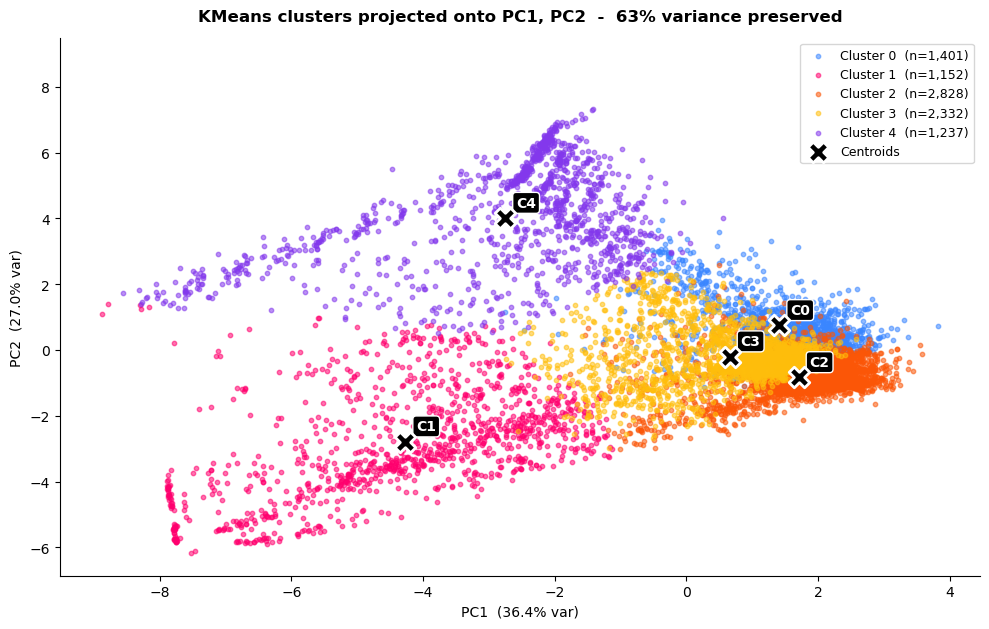

In [11]:
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_viz.fit_transform(X)
var_2d = pca_viz.explained_variance_ratio_.sum()
print(f"Variance preserved in 2D: {var_2d*100:.1f}%")

colors = ["#3a86ff", "#ff006e", "#fb5607", "#ffbe0b", "#8338ec"]

fig, ax = plt.subplots(figsize=(10, 6.4))
for c in range(K):
    mask = km_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors[c], s=10, alpha=0.55,
               label=f"Cluster {c}  (n={mask.sum():,})")

centroids_2d = pca_viz.transform(km.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker="X", c="black",
           s=220, edgecolor="white", linewidth=2, zorder=10, label="Centroids")

for c, (cx, cy) in enumerate(centroids_2d):
    ax.annotate(f"C{c}", xy=(cx, cy), xytext=(8, 8),
                textcoords="offset points", fontsize=10, fontweight="bold",
                color="white",
                bbox=dict(boxstyle="round,pad=0.25", fc="black", ec="white", lw=1))

ax.set_xlabel(f"PC1  ({pca_viz.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2  ({pca_viz.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"KMeans clusters projected onto PC1, PC2  -  {var_2d*100:.0f}% variance preserved")
y0, y1 = ax.get_ylim()
ax.set_ylim(y0, y1 + (y1 - y0) * 0.10)
ax.legend(loc="upper right", fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

### Seed stability (5 seeds, k=5)

In [12]:
seeds = [0, 1, 7, 42, 99]
seed_labels = []
for s in seeds:
    seed_labels.append(KMeans(n_clusters=K, n_init=10, random_state=s).fit(X).labels_)

seed_aris = []
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        seed_aris.append(adjusted_rand_score(seed_labels[i], seed_labels[j]))

print(f"ARI across {len(seeds)} seeds (KMeans, k={K}):")
print(f"  Mean: {np.mean(seed_aris):.3f}")
print(f"  Min:  {np.min(seed_aris):.3f}")
print(f"  Max:  {np.max(seed_aris):.3f}")

ARI across 5 seeds (KMeans, k=5):
  Mean: 0.992
  Min:  0.987
  Max:  1.000


In [13]:
subsample_aris = []
n = X.shape[0]
rng = np.random.RandomState(RANDOM_STATE)

for trial in range(5):
    idx = rng.choice(n, size=int(0.8 * n), replace=False)
    X_sub = X[idx]
    km_sub = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X_sub)
    ari = adjusted_rand_score(km_labels[idx], km_sub.labels_)
    subsample_aris.append(ari)
    print(f"  Subsample {trial+1} (n={len(idx)}): ARI to primary = {ari:.3f}")

print(f"\nSubsample stability: mean ARI = {np.mean(subsample_aris):.3f}, "
      f"min = {np.min(subsample_aris):.3f}")

  Subsample 1 (n=7160): ARI to primary = 0.984
  Subsample 2 (n=7160): ARI to primary = 0.985
  Subsample 3 (n=7160): ARI to primary = 0.968
  Subsample 4 (n=7160): ARI to primary = 0.987
  Subsample 5 (n=7160): ARI to primary = 0.987

Subsample stability: mean ARI = 0.982, min = 0.968


  Subsample 2 (n=7160): ARI to primary = 0.985


  Subsample 3 (n=7160): ARI to primary = 0.968


  Subsample 4 (n=7160): ARI to primary = 0.987


  Subsample 5 (n=7160): ARI to primary = 0.987

Subsample stability: mean ARI = 0.982, min = 0.968


In [14]:
pca5 = PCA(n_components=5, random_state=RANDOM_STATE)
X_5d = pca5.fit_transform(X)
print(f"Variance preserved in PCA-5: {pca5.explained_variance_ratio_.sum()*100:.1f}%")

km_5d = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X_5d)
ari_pca = adjusted_rand_score(km_labels, km_5d.labels_)
print(f"ARI between primary (18D) and PCA-5 clustering: {ari_pca:.3f}")

Variance preserved in PCA-5: 87.5%
ARI between primary (18D) and PCA-5 clustering: 0.954


ARI between primary (18D) and PCA-5 clustering: 0.954


### Validation summary

In [15]:
validation_summary = pd.DataFrame([
    ("Silhouette (primary, k=5)",
     f"{sil_km:.3f}"),
    ("Cluster sizes (sorted)",
     str(sorted(pd.Series(km_labels).value_counts().tolist()))),
    ("Seed stability (mean ARI, 5 seeds)",
     f"{np.mean(seed_aris):.3f}"),
    ("Subsample stability (mean ARI, 5x 80%)",
     f"{np.mean(subsample_aris):.3f}"),
    ("PCA-5 sensitivity (ARI to 18D)",
     f"{ari_pca:.3f}"),
    ("Ward sensitivity (ARI to KMeans)",
     f"{ari_km_ward:.3f}"),
    ("Manhattan attempt (best ARI)",
     f"{max(r['ARI_to_KMeans'] for r in manhattan_results):.3f} (failed)"),
], columns=["check", "value"])

print(validation_summary.to_string(index=False))

                                 check                          value
             Silhouette (primary, k=5)                          0.237
                Cluster sizes (sorted) [1152, 1237, 1401, 2332, 2828]
    Seed stability (mean ARI, 5 seeds)                          0.992
Subsample stability (mean ARI, 5x 80%)                          0.982
        PCA-5 sensitivity (ARI to 18D)                          0.954
      Ward sensitivity (ARI to KMeans)                          0.548
          Manhattan attempt (best ARI)                 0.168 (failed)


## Part 4 - Interrogate

For each cluster: which 2-3 features define it? Is any cluster just noise? I use two tools:
1. **Visual:** medians per cluster on key features (in original units).
2. **Statistical:** Kruskal-Wallis non-parametric test per feature with eta-squared effect size. Non-parametric because the data remains skewed even after log+scale.

In [16]:
df_profile = df_clean.copy()
df_profile["cluster"] = km_labels
profile_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS", "MINIMUM_PAYMENTS",
                "PRC_FULL_PAYMENT", "CREDIT_LIMIT",
                "utilization_ratio", "payment_to_min_ratio", "cash_advance_share"]
for c in ["utilization_ratio", "payment_to_min_ratio", "cash_advance_share"]:
    df_profile[c] = df_features[c].values

profile = df_profile.groupby("cluster")[profile_cols].median().round(2)
profile.insert(0, "size", df_profile.groupby("cluster").size())
profile.insert(1, "share_%", (profile["size"] / profile["size"].sum() * 100).round(1))
profile = profile.sort_values("size", ascending=False)

PERSONAS = {
    0: "Heavy spenders, elevated risk",
    1: "Dormant, minimal exposure",
    2: "Cash advance heavy, high risk",
    3: "Light revolvers, moderate risk",
    4: "Transactors, healthy, low risk",
}
profile.insert(0, "persona", [PERSONAS[c] for c in profile.index])

print("Cluster profile (medians in original units, sorted by size):\n")
print(profile.to_string())

Cluster profile (medians in original units, sorted by size):

                                persona  size  share_%  BALANCE  PURCHASES  CASH_ADVANCE  PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  CREDIT_LIMIT  utilization_ratio  payment_to_min_ratio  cash_advance_share
cluster                                                                                                                                                                                                          
2         Cash advance heavy, high risk  2828     31.6  1930.15       0.00       1488.24    986.08            654.81              0.00        3000.0               0.69                  1.09                 1.0
3        Light revolvers, moderate risk  2332     26.1   631.74     432.60          0.00    527.28            229.32              0.00        2275.0               0.26                  1.37                 0.0
0         Heavy spenders, elevated risk  1401     15.7  1906.28    2074.57          0.00   2055.67


                                persona  size  share_%  BALANCE  PURCHASES  CASH_ADVANCE  PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  CREDIT_LIMIT  utilization_ratio  payment_to_min_ratio  cash_advance_share
cluster                                                                                                                                                                                                          
2         Cash advance heavy, high risk  2828     31.6  1930.15       0.00       1488.24    986.08            654.81              0.00        3000.0               0.69                  1.09                 1.0
3        Light revolvers, moderate risk  2332     26.1   631.74     432.60          0.00    527.28            229.32              0.00        2275.0               0.26                  1.37                 0.0
0         Heavy spenders, elevated risk  1401     15.7  1906.28    2074.57          0.00   2055.67            621.42              0.00        6500.0           

In [17]:
def kruskal_eta_squared(values_by_group, n_total):
    H, p = kruskal(*values_by_group)
    k = len(values_by_group)
    eta2 = (H - k + 1) / (n_total - k)
    return H, p, max(eta2, 0)

kw_records = []
for col in df_features.columns:
    groups = [df_features.loc[df_profile["cluster"] == c, col].values for c in range(K)]
    H, p, eta2 = kruskal_eta_squared(groups, len(df_features))
    kw_records.append({"feature": col, "H": round(H, 1), "eta_squared": round(eta2, 3)})

kw_df = pd.DataFrame(kw_records).sort_values("eta_squared", ascending=False).reset_index(drop=True)

def _effect_label(e):
    if e >= 0.14: return "large"
    if e >= 0.06: return "moderate"
    return "small"

kw_df["effect"] = kw_df["eta_squared"].apply(_effect_label)

print("Kruskal-Wallis per feature, sorted by effect size")
print("(p-values omitted: n=8,950 makes them all ~0)\n")
print(kw_df.to_string(index=False))

Kruskal-Wallis per feature, sorted by effect size
(p-values omitted: n=8,950 makes them all ~0)

                         feature      H  eta_squared   effect
              cash_advance_share 5759.0        0.643    large
          CASH_ADVANCE_FREQUENCY 5321.1        0.594    large
                CASH_ADVANCE_TRX 5247.5        0.586    large
                    CASH_ADVANCE 4935.7        0.551    large
                         BALANCE 4924.1        0.550    large
                   PURCHASES_TRX 4779.6        0.534    large
               BALANCE_FREQUENCY 4752.5        0.531    large
                PRC_FULL_PAYMENT 4581.8        0.512    large
               utilization_ratio 4464.5        0.499    large
             PURCHASES_FREQUENCY 4444.3        0.496    large
                MINIMUM_PAYMENTS 3938.5        0.440    large
      ONEOFF_PURCHASES_FREQUENCY 3473.7        0.388    large
                ONEOFF_PURCHASES 3150.6        0.352    large
          INSTALLMENTS_PURCHASES 27

In [18]:
print("Top defining features per cluster (deviation from global median):\n")
global_med = df_features.median()
iqr = df_features.quantile(0.75) - df_features.quantile(0.25)

for c in range(K):
    cluster_med = df_features.loc[df_profile["cluster"] == c].median()
    deviation = (cluster_med - global_med) / iqr.replace(0, 1)
    top = deviation.abs().sort_values(ascending=False).head(3)
    n_c = int((km_labels == c).sum())
    print(f"Cluster {c} (n={n_c}):")
    for feat in top.index:
        sign = "HIGH" if deviation[feat] > 0 else "LOW"
        print(f"  {feat:<28s} {sign}  (cluster_median={cluster_med[feat]:.2f}, "
              f"global_median={global_med[feat]:.2f})")
    print()

Top defining features per cluster (deviation from global median):

Cluster 0 (n=1401):
  ONEOFF_PURCHASES             HIGH  (cluster_median=1295.84, global_median=38.00)
  ONEOFF_PURCHASES_FREQUENCY   HIGH  (cluster_median=0.67, global_median=0.08)
  PURCHASES_TRX                HIGH  (cluster_median=30.00, global_median=7.00)

Cluster 1 (n=1152):
  BALANCE_FREQUENCY            LOW  (cluster_median=0.36, global_median=1.00)
  BALANCE                      LOW  (cluster_median=25.48, global_median=873.39)
  utilization_ratio            LOW  (cluster_median=0.01, global_median=0.30)

Cluster 2 (n=2828):
  CASH_ADVANCE                 HIGH  (cluster_median=1488.24, global_median=0.00)
  CASH_ADVANCE_TRX             HIGH  (cluster_median=5.00, global_median=0.00)
  CASH_ADVANCE_FREQUENCY       HIGH  (cluster_median=0.25, global_median=0.00)

Cluster 3 (n=2332):
  PURCHASES_INSTALLMENTS_FREQUENCY HIGH  (cluster_median=0.50, global_median=0.17)
  INSTALLMENTS_PURCHASES       HIGH  (cluster_me

---
## Appendix - Decision Tree

The 13-station decision map with the chosen option per station, top-down.

Interactive Plotly figure: **mouse wheel to zoom**, **drag to pan**, **hover on any dilemma or chosen line for a tooltip**, double-click to reset.

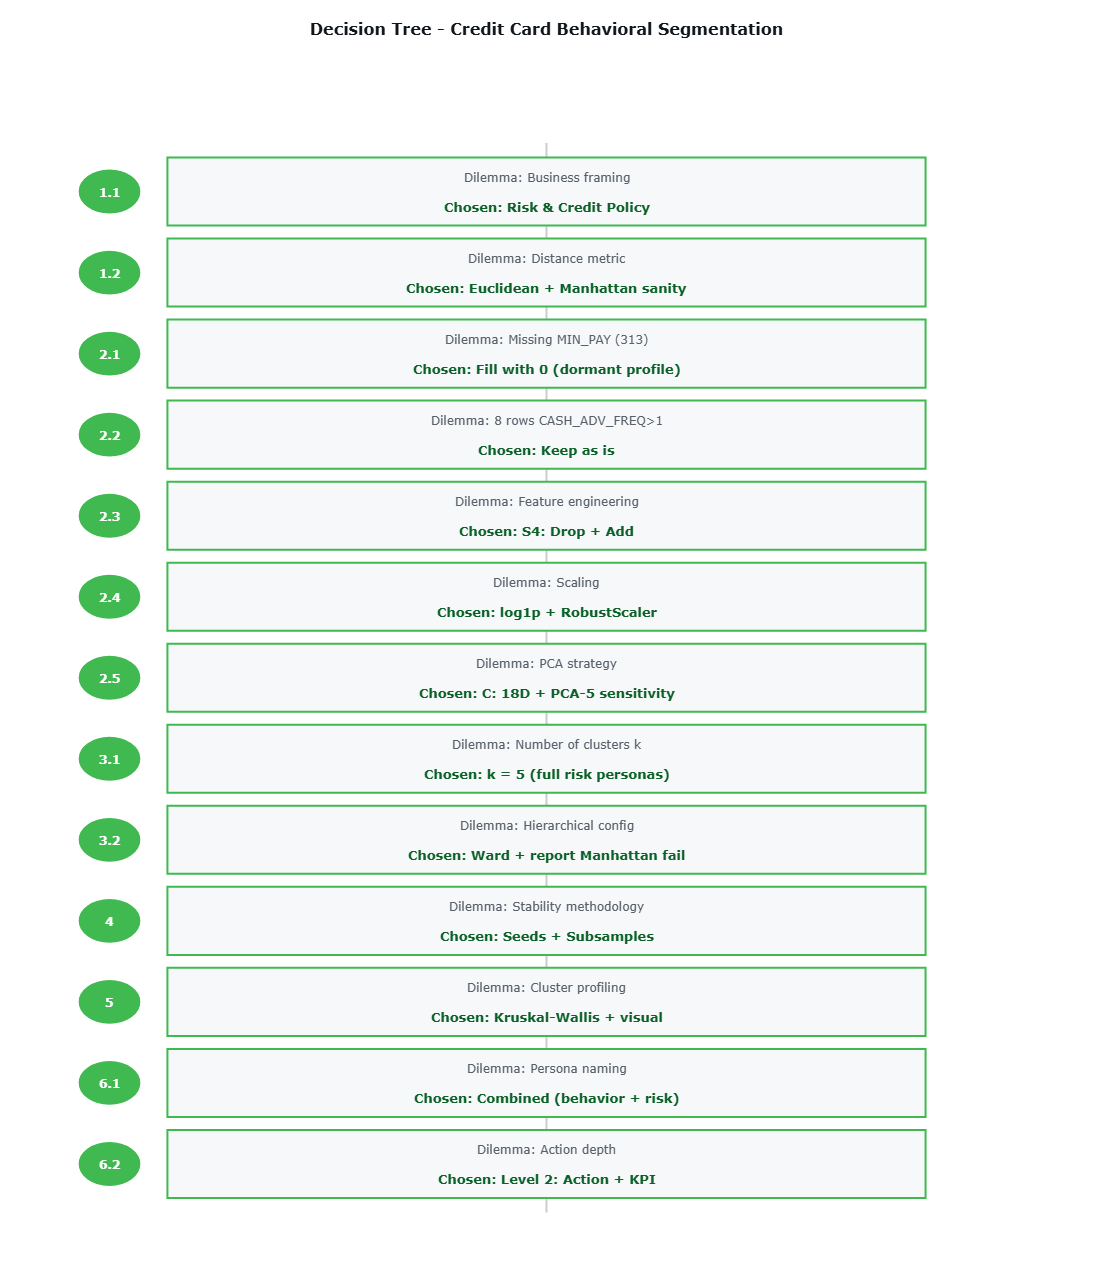

In [19]:
STATIONS = [
    ("1.1", "Business framing",       "Risk & Credit Policy"),
    ("1.2", "Distance metric",        "Euclidean + Manhattan sanity"),
    ("2.1", "Missing MIN_PAY (313)",  "Fill with 0 (dormant profile)"),
    ("2.2", "8 rows CASH_ADV_FREQ>1", "Keep as is"),
    ("2.3", "Feature engineering",    "S4: Drop + Add"),
    ("2.4", "Scaling",                "log1p + RobustScaler"),
    ("2.5", "PCA strategy",           "C: 18D + PCA-5 sensitivity"),
    ("3.1", "Number of clusters k",   "k = 5 (full risk personas)"),
    ("3.2", "Hierarchical config",    "Ward + report Manhattan fail"),
    ("4",   "Stability methodology",  "Seeds + Subsamples"),
    ("5",   "Cluster profiling",      "Kruskal-Wallis + visual"),
    ("6.1", "Persona naming",         "Combined (behavior + risk)"),
    ("6.2", "Action depth",           "Level 2: Action + KPI"),
]

TITLE     = "Decision Tree - Credit Card Behavioral Segmentation"
CARD_BG   = "#f6f8fa"
CARD_EDGE = "#3fb950"
BADGE_BG  = "#3fb950"
SPINE     = "#c8ced4"
DILEMMA   = "#586069"
CHOSEN    = "#0b6127"
PLOT_CFG  = {"scrollZoom": True, "displaylogo": False,
             "modeBarButtonsToRemove": ["lasso2d", "select2d"]}


def _add_hover_marker(fig, x, y, text):
    fig.add_trace(go.Scatter(
        x=[x], y=[y], mode="markers",
        marker=dict(size=1, color="rgba(0,0,0,0)"),
        hovertext=text, hoverinfo="text",
        showlegend=False,
    ))


def make_TD():
    n = len(STATIONS)
    fig = go.Figure()
    fig.add_shape(type="line", x0=5, y0=0.4, x1=5, y1=n + 0.6,
                  line=dict(color=SPINE, width=2))
    for i, (num, dilemma, chosen) in enumerate(STATIONS):
        y = n - i
        fig.add_shape(type="rect", x0=1.4, y0=y - 0.42, x1=8.6, y1=y + 0.42,
                      line=dict(color=CARD_EDGE, width=2), fillcolor=CARD_BG)
        fig.add_shape(type="circle", x0=0.55, y0=y - 0.28, x1=1.15, y1=y + 0.28,
                      line=dict(color="white", width=1.5), fillcolor=BADGE_BG)
        fig.add_annotation(x=0.85, y=y, text=f"<b>{num}</b>",
                           showarrow=False, font=dict(color="white", size=12))
        fig.add_annotation(x=5, y=y + 0.18, text=f"Dilemma: {dilemma}",
                           showarrow=False, font=dict(color=DILEMMA, size=12))
        fig.add_annotation(x=5, y=y - 0.18, text=f"<b>Chosen: {chosen}</b>",
                           showarrow=False, font=dict(color=CHOSEN, size=13))
        _add_hover_marker(fig, 5, y, f"<b>Station {num}</b><br>Dilemma: {dilemma}<br>Chosen: {chosen}")
    fig.update_layout(
        title=dict(text=f"<b>{TITLE}</b>", x=0.5, xanchor="center",
                   font=dict(size=16, color="#11161c")),
        width=1100, height=1250,
        xaxis=dict(visible=False, range=[0, 10]),
        yaxis=dict(visible=False, range=[0, n + 1.5]),
        showlegend=False,
        plot_bgcolor="white", paper_bgcolor="white",
        margin=dict(l=20, r=20, t=70, b=20),
        hovermode="closest",
        dragmode="pan",
    )
    return fig


make_TD().show(config=PLOT_CFG)

In [26]:
from pathlib import Path
from IPython.display import Markdown, display

mmd_path = Path("decision_tree.mmd")
if mmd_path.exists():
    display(Markdown(f"```mermaid\n{mmd_path.read_text(encoding='utf-8')}\n```"))
else:
    print("decision_tree.mmd not found next to the notebook.")

```mermaid
%%{init: {'theme':'dark', 'themeVariables': {'darkMode': true}}}%%
flowchart TD

    %% Style classes
    classDef station fill:#11161c,stroke:#666,color:#fff,stroke-width:2px,font-weight:bold
    classDef chosen fill:#1f2937,stroke:#3fb950,color:#fff,stroke-width:3px
    classDef rejected fill:#161b22,stroke:#3a4147,color:#6e7681,stroke-width:1px
    classDef rationale fill:#0a0e14,stroke:#3fb950,stroke-dasharray:3 3,color:#8b949e,font-style:italic

    S1["Station 1.1<br/><b>Business Framing</b>"]
    S1O1["Marketing & Upsell"]
    S1 -.-> S1O1
    S1O2["Risk & Credit Policy"]
    S1 ==> S1O2
    S1R(["why: All 17 features are financial-behavioral and tie directly to credit risk. The honest trade-off is no ground-truth labels..."])
    S1O2 -.-> S1R
    S1O3["Engagement & Retention"]
    S1 -.-> S1O3
    S1O4["Product Cross-sell"]
    S1 -.-> S1O4

    S2["Station 1.2<br/><b>Distance Metric</b>"]
    S1O2 ==> S2
    S2O1["Euclidean only"]
    S2 -.-> S2O1
    S2O2["Euclidean + Manhattan sanity"]
    S2 ==> S2O2
    S2R(["why: In a risk story, magnitude IS the story. Manhattan sanity check tests whether structure survives geometry change. Spoile..."])
    S2O2 -.-> S2R
    S2O3["Cosine"]
    S2 -.-> S2O3
    S2O4["Manhattan only"]
    S2 -.-> S2O4

    S3["Station 2.1<br/><b>Missing Values</b>"]
    S2O2 ==> S3
    S3O1["Drop rows"]
    S3 -.-> S3O1
    S3O2["Fill with median (~312)"]
    S3 -.-> S3O2
    S3O3["Fill with 0"]
    S3 ==> S3O3
    S3R(["why: Missing values are patterned, not random. All 313 have BAL near 0 and PRC_FULL_PAYMENT = 0. Fill with 0 carries the trut..."])
    S3O3 -.-> S3R
    S3O4["KNN imputation"]
    S3 -.-> S3O4

    S4["Station 2.2<br/><b>Out-of-range Values</b>"]
    S3O3 ==> S4
    S4O1["Keep as is"]
    S4 ==> S4O1
    S4R(["why: Preserve extreme behavioral signals. These 8 customers are the highest risk on the cash-advance dimension."])
    S4O1 -.-> S4R
    S4O2["Cap at 1.0"]
    S4 -.-> S4O2

    S5["Station 2.3<br/><b>Feature Engineering</b>"]
    S4O1 ==> S5
    S5O1["S1: All 17 features"]
    S5 -.-> S5O1
    S5O2["S2: Drop redundant only"]
    S5 -.-> S5O2
    S5O3["S3: Add risk features only"]
    S5 -.-> S5O3
    S5O4["S4: Drop + Add"]
    S5 ==> S5O4
    S5R(["why: cash_advance_share emerged as the #1 cluster discriminator (eta-squared 0.643), validating the engineering."])
    S5O4 -.-> S5R

    S6["Station 2.4<br/><b>Scaling Method</b>"]
    S5O4 ==> S6
    S6O1["StandardScaler only"]
    S6 -.-> S6O1
    S6O2["log1p + StandardScaler"]
    S6 -.-> S6O2
    S6O3["log1p + RobustScaler"]
    S6 ==> S6O3
    S6R(["why: Two problems want two tools. log1p for skew, RobustScaler for remaining outliers. Only candidate with ARI > 0.99."])
    S6O3 -.-> S6R
    S6O4["PowerTransformer (Yeo-J)"]
    S6 -.-> S6O4

    S7["Station 2.5<br/><b>PCA Strategy</b>"]
    S6O3 ==> S7
    S7O1["A: 2D viz only"]
    S7 -.-> S7O1
    S7O2["B: Reduce before clustering"]
    S7 -.-> S7O2
    S7O3["C: 18D + PCA-5 sensitivity + viz"]
    S7 ==> S7O3
    S7R(["why: PCA-5 sensitivity check gave ARI 0.954 to 18D primary. Strong evidence structure is not a dimensionality artifact."])
    S7O3 -.-> S7R
    S7O4["D: No PCA at all"]
    S7 -.-> S7O4

    S8["Station 3.1<br/><b>Number of Clusters</b>"]
    S7O3 ==> S8
    S8O1["k=3 (metric-optimal)"]
    S8 -.-> S8O1
    S8O2["k=4 (compromise)"]
    S8 -.-> S8O2
    S8O3["k=5 (full risk personas)"]
    S8 ==> S8O3
    S8R(["why: Metrics measure how cleanly the data partitions, not how usefully. Silhouette has no business unit."])
    S8O3 -.-> S8R
    S8O4["k=6 (split dormant)"]
    S8 -.-> S8O4

    S9["Station 3.2<br/><b>Hierarchical Configuration</b>"]
    S8O3 ==> S9
    S9O1["A: Pivot to Ward (simple)"]
    S9 -.-> S9O1
    S9O2["B: Ward + report Manhattan fail"]
    S9 ==> S9O2
    S9R(["why: Manhattan failure is itself a finding: structure is geometry-dependent. Ward gives ARI 0.548 at k=5, 0.833 at k=3."])
    S9O2 -.-> S9R
    S9O3["C: Add DBSCAN as 3rd method"]
    S9 -.-> S9O3
    S9O4["D: Stick with Manhattan"]
    S9 -.-> S9O4

    S10["Station 4<br/><b>Stability Methodology</b>"]
    S9O2 ==> S10
    S10O1["A: Seeds only"]
    S10 -.-> S10O1
    S10O2["B: Seeds + Subsamples"]
    S10 ==> S10O2
    S10R(["why: B answers exactly the question, no more. Result: seeds ARI 0.992, subsamples ARI 0.982."])
    S10O2 -.-> S10R
    S10O3["C: + Bootstrap (50x)"]
    S10 -.-> S10O3
    S10O4["D: + Adversarial"]
    S10 -.-> S10O4

    S11["Station 5<br/><b>Cluster Profiling</b>"]
    S10O2 ==> S11
    S11O1["A: Visual only"]
    S11 -.-> S11O1
    S11O2["B: Kruskal-Wallis + visual"]
    S11 ==> S11O2
    S11R(["why: p-values useless with n=8950. Eta-squared gives effect size. Non-parametric matters because features stay skewed."])
    S11O2 -.-> S11R
    S11O3["C: Random Forest importance"]
    S11 -.-> S11O3
    S11O4["D: All three combined"]
    S11 -.-> S11O4

    S12["Station 6.1<br/><b>Persona Naming</b>"]
    S11O2 ==> S12
    S12O1["A: Risk-tiered"]
    S12 -.-> S12O1
    S12O2["B: Behavioral"]
    S12 -.-> S12O2
    S12O3["C: Combined"]
    S12 ==> S12O3
    S12R(["why: Risk framing needs the risk level visible. Combined names deliver both signals at once."])
    S12O3 -.-> S12R
    S12O4["D: Custom hybrid"]
    S12 -.-> S12O4

    S13["Station 6.2<br/><b>Action Depth</b>"]
    S12O3 ==> S13
    S13O1["Level 1: Action only"]
    S13 -.-> S13O1
    S13O2["Level 2: Action + KPI"]
    S13 ==> S13O2
    S13R(["why: KPI turns an idea into a plan. Level 2 is the analyst standard. Level 3 reserved for REPORT Q8."])
    S13O2 -.-> S13R
    S13O3["Level 3: + False positive cost"]
    S13 -.-> S13O3

    %% Apply styles
    class S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13 station
    class S1O2,S2O2,S3O3,S4O1,S5O4,S6O3,S7O3,S8O3,S9O2,S10O2,S11O2,S12O3,S13O2 chosen
    class S1O1,S1O3,S1O4,S2O1,S2O3,S2O4,S3O1,S3O2,S3O4,S4O2,S5O1,S5O2,S5O3,S6O1,S6O2,S6O4,S7O1,S7O2,S7O4,S8O1,S8O2,S8O4,S9O1,S9O3,S9O4,S10O1,S10O3,S10O4,S11O1,S11O3,S11O4,S12O1,S12O2,S12O4,S13O1,S13O3 rejected
    class S1R,S2R,S3R,S4R,S5R,S6R,S7R,S8R,S9R,S10R,S11R,S12R,S13R rationale
```